# LLM-Driven Ontology Generation: IAEDU Pipeline Demonstration



This notebook mirrors the standard pipeline demo but uses the IAEDU-backed option in `ChatGpt` for end-to-end testing.



We'll walk through all 4 phases:

1. **Structured Seed** — Generate a multi-level taxonomic skeleton

2. **Structural Validation** — Validate and prune the seed structure

3. **UCB1 Expansion** — Iteratively expand the ontology using a multi-armed bandit

4. **RDF Serialization** — Emit hierarchical RDF triples and visualize


## Setup



Configure the IAEDU-backed LLM client and ontology parameters.


In [1]:
import json
import logging
import os
from ontogen import ChatGpt, Ontology, DEFAULT_LEVEL_SCHEMA

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    force=True,
    )

# IAEDU-backed configuration
DOMAIN = "Star Trek"  # Change this to explore other domains
API_KEY = os.getenv("IAEDU_API_KEY", "")
ENDPOINT = os.getenv(
    "IAEDU_ENDPOINT",
    "https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream",
)

CHANNEL_ID = os.getenv("IAEDU_CHANNEL_ID", "cmj1i57292iz9lq01goukbuuv")
PROVIDER = "iaedu"
TIMEOUT = 60
SEED_SIZE = 3  # Number of top-level classes to seed
MAX_ITERATIONS = 60  # Max expansion iterations
CANDIDATES_PER_ITERATION = 3  # Number of candidate relationships to evaluate per iteration
EXPLORATION_CONSTANT = 0.15  # UCB1 exploration parameter
SIMILARITY_THRESHOLD = 70  # Minimum similarity (0-100) to accept relationships
MAX_WORKERS = 2  # IAEDU is sensitive to request bursts during similarity batches
MIN_REQUEST_INTERVAL_SECONDS = 1.0  # Minimum delay between request start times
MAX_CONCURRENT_REQUESTS = 2  # Serialize IAEDU requests to avoid 429 bursts
CLASS_DISCOVERTY_INTERVAL = 50  # Perform class discovery every N iterations to find new candidate classes

print(f"Domain: {DOMAIN}")
print(f"Provider: {PROVIDER}")
print(f"API Key configured: {bool(API_KEY)}")
print(f"Endpoint: {ENDPOINT}")
print(f"Channel ID: {CHANNEL_ID}")
print(f"Ontology workers: {MAX_WORKERS}")
print(f"Request interval seconds: {MIN_REQUEST_INTERVAL_SECONDS}")
print(f"Max concurrent requests: {MAX_CONCURRENT_REQUESTS}")
print(f"Default level schema: {[level.name for level in DEFAULT_LEVEL_SCHEMA]}")


/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.1.0) or chardet (6.0.0.post1)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


Domain: Star Trek
Provider: iaedu
API Key configured: True
Endpoint: https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream
Channel ID: cmj1i57292iz9lq01goukbuuv
Ontology workers: 2
Request interval seconds: 1.0
Max concurrent requests: 2
Default level schema: ['class', 'subclass', 'instance']


In [2]:
# Initialize IAEDU-backed LLM client and ontology

agent = ChatGpt(
    api_key=API_KEY,
    provider=PROVIDER,
    endpoint=ENDPOINT,
    channel_id=CHANNEL_ID,
    timeout=TIMEOUT,
    min_request_interval_seconds=MIN_REQUEST_INTERVAL_SECONDS,
    max_concurrent_requests=MAX_CONCURRENT_REQUESTS,
)

ontology = Ontology(
    domain=DOMAIN,
    agent=agent,
    level_schema=DEFAULT_LEVEL_SCHEMA,
    exploration_constant=EXPLORATION_CONSTANT,
    candidates_per_iteration=CANDIDATES_PER_ITERATION,
    max_iterations=MAX_ITERATIONS,
    similarity_threshold=SIMILARITY_THRESHOLD,
    max_workers=MAX_WORKERS,
    class_discovery_interval=CLASS_DISCOVERTY_INTERVAL,
)

print(f"Ontology initialized for domain: {ontology.domain}")
print(f"LLM provider: {agent.provider}")
print(f"Request policy: {agent.describe_request_policy()}")

2026-04-08 00:39:30,511 | INFO | ontogen.llm_client | Initialized iaedu client (provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00)


Ontology initialized for domain: Star Trek
LLM provider: iaedu
Request policy: provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00


## Phase 1: Structured Seed

Generate a multi-level taxonomic skeleton from the domain using the LLM.
The seed captures the initial structure with classes, subclasses, and instances.

In [3]:
# Generate structured seed taxonomy
print(f"Generating {SEED_SIZE}-level taxonomic skeleton for '{DOMAIN}'...")
seed = ontology.generate_initial_terms(num_classes=SEED_SIZE)

if seed:
    print(f"\nSeed domain: {seed.get('domain')}")
    print(f"Number of top-level classes: {len(seed.get('taxonomy', []))}")
    print("\nRaw seed taxonomy (JSON):")
    print(json.dumps(seed, indent=2))

else:
    print("ERROR: Seed generation failed. Check IAEDU credentials and try again.")


Generating 3-level taxonomic skeleton for 'Star Trek'...


2026-04-08 00:39:36,423 | INFO | ontogen.llm_client | [IAEDU #1] 'iaedu-chat' completed in 5.90s (slot_wait=0.00s, throttle_wait=0.00s, events=991, output_chars=4959)
2026-04-08 00:39:36,424 | INFO | ontogen.ontology | Parsed seed successfully: domain=Star Trek, taxonomy count=3



Seed domain: Star Trek
Number of top-level classes: 3

Raw seed taxonomy (JSON):
{
  "domain": "Star Trek",
  "taxonomy": [
    {
      "class": "Species",
      "description": "Intelligent life forms and civilizations in the Star Trek universe.",
      "subclasses": [
        {
          "class": "Humanoids",
          "description": "Species with human-like physical characteristics.",
          "instances": [
            {
              "term": "Vulcans",
              "description": "A logical and emotion-suppressing species from the planet Vulcan."
            },
            {
              "term": "Klingons",
              "description": "A warrior species known for their honor and combat skills."
            },
            {
              "term": "Betazoids",
              "description": "A telepathic species known for their empathic abilities."
            }
          ]
        },
        {
          "class": "Non-Humanoids",
          "description": "Species with non-human phy

## Phase 2: Structural Validation

Convert the seed to a graph and validate its structure using pairwise LLM similarity checks.
This phase prunes weak edges and identifies any orphaned nodes.

In [4]:
# Create DiGraph from seed
print("Converting seed taxonomy to internal graph...")
ontology.create_seed_ontology()

if ontology.ontology_graph.number_of_nodes() > 0:
    print(f"Graph created: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")
    print(f"\nNodes by level:")
    for level in DEFAULT_LEVEL_SCHEMA:
        nodes_at_level = [n for n, d in ontology.ontology_graph.nodes(data=True) if d.get('level') == level.name]
        print(f"  {level.name}: {len(nodes_at_level)} nodes ({', '.join(nodes_at_level[:3])}{'...' if len(nodes_at_level) > 3 else ''})")
else:
    print("ERROR: Graph creation failed.")

2026-04-08 00:39:36,443 | INFO | ontogen.ontology | Created seed ontology with 31 nodes


Converting seed taxonomy to internal graph...
Graph created: 31 nodes, 28 edges

Nodes by level:
  class: 3 nodes (Species, Starships, Technology)
  subclass: 9 nodes (Humanoids, Non-Humanoids, Artificial Life Forms...)
  instance: 19 nodes (Vulcans, Klingons, Betazoids...)


In [5]:
# Validate structure: check parent-child relationships with timed similarity batches
print("\nValidating structure with pairwise similarity checks...")
validation_summary = ontology.validate_structure()

print("\nValidation Summary:")
for key, value in validation_summary.items():
    print(f"  {key}: {value}")

print(f"\nGraph after validation: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")

2026-04-08 00:39:36,456 | INFO | ontogen.ontology | Generated 28 parent-child validation pairs
2026-04-08 00:39:36,458 | INFO | ontogen.ontology | [Phase 3 validation] Starting similarity batch: total_pairs=28, uncached_pairs=28, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:39:36,459 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Species, Humanoids)
2026-04-08 00:39:36,460 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Species, Non-Humanoids)
2026-04-08 00:39:36,464 | INFO | ontogen.llm_client | [IAEDU #3] Throttling 'Phase 3 validation' for 1.00s



Validating structure with pairwise similarity checks...


2026-04-08 00:39:37,749 | INFO | ontogen.llm_client | [IAEDU #2] 'Phase 3 validation' completed in 1.29s (slot_wait=0.00s, throttle_wait=0.00s, events=63, output_chars=242)
2026-04-08 00:39:37,752 | INFO | ontogen.ontology | [Phase 3 validation] Similarity(Species, Humanoids) = 75.000000
2026-04-08 00:39:37,753 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Species, Artificial Life Forms)
2026-04-08 00:39:37,756 | INFO | ontogen.llm_client | [IAEDU #4] Throttling 'Phase 3 validation' for 0.71s
2026-04-08 00:39:39,600 | INFO | ontogen.llm_client | [IAEDU #3] 'Phase 3 validation' completed in 2.14s (slot_wait=0.00s, throttle_wait=1.00s, events=65, output_chars=235)
2026-04-08 00:39:39,602 | INFO | ontogen.ontology | [Phase 3 validation] Similarity(Species, Non-Humanoids) = 75.000000
2026-04-08 00:39:39,603 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Humanoids, Vulcans)
2026-04-08 00:39:40,631 | INFO | ontogen.llm_


Validation Summary:
  edges_pruned: 1
  orphaned_nodes: 1

Graph after validation: 31 nodes, 27 edges


## Phase 3: UCB1 Expansion

Iteratively expand the ontology using a multi-armed bandit (UCB1) strategy.
For each iteration, we select the most promising expandable node and generate new candidates.

2026-04-08 00:40:08,297 | INFO | ontogen.ontology | Phase 1: Generating seed from domain Star Trek


Running full pipeline with max_iterations=60...
Similarity threshold: 70
Exploration constant (UCB1): 0.15
IAEDU request policy: provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
Ontology worker count: 2


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 1: Seed Generation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


2026-04-08 00:40:14,431 | INFO | ontogen.llm_client | [IAEDU #30] 'iaedu-chat' completed in 6.13s (slot_wait=0.00s, throttle_wait=0.00s, events=1156, output_chars=5741)
2026-04-08 00:40:14,433 | INFO | ontogen.ontology | Parsed seed successfully: domain=Star Trek, taxonomy count=5
2026-04-08 00:40:14,435 | INFO | ontogen.ontology | Seed generated: 5 top-level classes
2026-04-08 00:40:14,437 | INFO | ontogen.ontology | Phase 2: Converting seed to ontology graph
2026-04-08 00:40:14,438 | INFO | ontogen.ontology | Created seed ontology with 36 nodes
2026-04-08 00:40:14,439 | INFO | ontogen.ontology | Ontology graph created: 36 nodes, 31 edges
2026-04-08 00:40:14,440 | INFO | ontogen.ontology | Phase 3: Validating structure and pruning weak edges
2026-04-08 00:40:14,442 | INFO | ontogen.ontology | Generated 31 parent-child validation pairs
2026-04-08 00:40:14,443 | INFO | ontogen.ontology | [Phase 3 validation] Starting similarity batch: total_pairs=31, uncached_pairs=15, workers=2, provid

  ✓ Generated 5 top-level classes (6.1s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 2: Graph Construction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Created graph: 36 nodes, 31 edges (0.0s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 3: Structural Validation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


2026-04-08 00:40:15,791 | INFO | ontogen.llm_client | [IAEDU #31] 'Phase 3 validation' completed in 1.34s (slot_wait=0.00s, throttle_wait=0.00s, events=69, output_chars=259)
2026-04-08 00:40:15,793 | INFO | ontogen.ontology | [Phase 3 validation] Similarity(Federation Starships, USS Enterprise) = 85.000000
2026-04-08 00:40:15,795 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Planets, Federation Planets)
2026-04-08 00:40:15,796 | INFO | ontogen.llm_client | [IAEDU #33] Throttling 'Phase 3 validation' for 0.65s
2026-04-08 00:40:16,678 | INFO | ontogen.llm_client | [IAEDU #32] 'Phase 3 validation' completed in 1.23s (slot_wait=0.00s, throttle_wait=1.00s, events=68, output_chars=225)
2026-04-08 00:40:16,680 | INFO | ontogen.ontology | [Phase 3 validation] Similarity(Klingon Starships, Negh'Var) = 85.000000
2026-04-08 00:40:16,682 | INFO | ontogen.ontology | [Phase 3 validation] Cache miss: evaluating similarity(Planets, Non-Federation Planets)
2026-04-0

  ✓ Pruned 1 edges, 1 orphaned nodes (16.4s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 4: UCB1 Iterative Expansion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Iter  Node                   Gen   Acc    Rate   Reward  Nodes  Edges  Status
  ────  ────────────────────  ────  ────  ──────  ───────  ─────  ─────  ────────────


2026-04-08 00:40:36,356 | INFO | ontogen.llm_client | [IAEDU #46] 'iaedu-chat' completed in 2.21s (slot_wait=0.00s, throttle_wait=0.00s, events=105, output_chars=485)
2026-04-08 00:40:36,359 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Species'
2026-04-08 00:40:36,360 | INFO | ontogen.ontology | Generated 3 candidates for 'Species'
2026-04-08 00:40:36,361 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Species' (threshold=70.0%)
2026-04-08 00:40:36,363 | INFO | ontogen.ontology | [Phase 4 candidate validation for Species] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:40:36,365 | INFO | ontogen.ontology | [Phase 4 candidate validation for Species] Cache miss: evaluating similarity(Species, Energy Beings)
2026-04-08 00:40:36,368 | INFO | ontogen.ontology | [Phase 4 candidate validation for Species] Cache miss: evaluating similarity(Species, Arti

     1  Species                  3     3   100%    0.817     39     33  


2026-04-08 00:40:57,213 | INFO | ontogen.llm_client | [IAEDU #62] 'iaedu-chat' completed in 1.68s (slot_wait=0.00s, throttle_wait=0.00s, events=108, output_chars=417)
2026-04-08 00:40:57,215 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Humanoids'
2026-04-08 00:40:57,217 | INFO | ontogen.ontology | Generated 3 candidates for 'Humanoids'
2026-04-08 00:40:57,218 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Humanoids' (threshold=70.0%)
2026-04-08 00:40:57,220 | INFO | ontogen.ontology | [Phase 4 candidate validation for Humanoids] Starting similarity batch: total_pairs=3, uncached_pairs=2, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:40:57,222 | INFO | ontogen.ontology | [Phase 4 candidate validation for Humanoids] Cache miss: evaluating similarity(Humanoids, Andorians)
2026-04-08 00:40:57,224 | INFO | ontogen.ontology | [Phase 4 candidate validation for Humanoids] Cache miss: evaluating similarity(Hum

     2  Humanoids                3     2    67%    0.567     41     36  


2026-04-08 00:41:09,869 | INFO | ontogen.llm_client | [IAEDU #73] 'iaedu-chat' completed in 1.94s (slot_wait=0.00s, throttle_wait=0.00s, events=123, output_chars=516)
2026-04-08 00:41:09,872 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Non-Humanoids'
2026-04-08 00:41:09,873 | INFO | ontogen.ontology | Generated 3 candidates for 'Non-Humanoids'
2026-04-08 00:41:09,874 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Non-Humanoids' (threshold=70.0%)
2026-04-08 00:41:09,876 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Humanoids] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:41:09,877 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Humanoids] Cache miss: evaluating similarity(Non-Humanoids, Medusans)
2026-04-08 00:41:09,878 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Humanoids] Cache miss

     3  Non-Humanoids            3     3   100%    0.817     44     39  


2026-04-08 00:41:30,562 | INFO | ontogen.llm_client | [IAEDU #89] 'iaedu-chat' completed in 1.78s (slot_wait=0.00s, throttle_wait=0.00s, events=118, output_chars=513)
2026-04-08 00:41:30,564 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Starships'
2026-04-08 00:41:30,566 | INFO | ontogen.ontology | Generated 3 candidates for 'Starships'
2026-04-08 00:41:30,568 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Starships' (threshold=70.0%)
2026-04-08 00:41:30,570 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:41:30,572 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Cache miss: evaluating similarity(Starships, Romulan Warbirds)
2026-04-08 00:41:30,573 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Cache miss: evaluating similar

     4  Starships                3     3   100%    0.850     47     45  


2026-04-08 00:41:48,696 | INFO | ontogen.llm_client | [IAEDU #105] 'iaedu-chat' completed in 2.51s (slot_wait=0.00s, throttle_wait=0.00s, events=99, output_chars=432)
2026-04-08 00:41:48,698 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Starships'
2026-04-08 00:41:48,700 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Starships'
2026-04-08 00:41:48,701 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Starships' (threshold=70.0%)
2026-04-08 00:41:48,702 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:41:48,703 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Starships] Cache miss: evaluating similarity(Federation Starships, USS Defiant)
2026-04-08 00:41:48,709 | INFO | ontogen.ontology | [Phase 4 candi

     5  Federation Starships     3     3   100%    0.850     50     51  plateau(1)


2026-04-08 00:42:09,460 | INFO | ontogen.llm_client | [IAEDU #121] 'iaedu-chat' completed in 1.93s (slot_wait=0.00s, throttle_wait=0.00s, events=119, output_chars=479)
2026-04-08 00:42:09,462 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Klingon Starships'
2026-04-08 00:42:09,466 | INFO | ontogen.ontology | Generated 3 candidates for 'Klingon Starships'
2026-04-08 00:42:09,467 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Klingon Starships' (threshold=70.0%)
2026-04-08 00:42:09,469 | INFO | ontogen.ontology | [Phase 4 candidate validation for Klingon Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:42:09,470 | INFO | ontogen.ontology | [Phase 4 candidate validation for Klingon Starships] Cache miss: evaluating similarity(Klingon Starships, Vor'cha-class Attack Cruiser)
2026-04-08 00:42:09,472 | INFO | ontogen.ontology | [Phase 4 candi

     6  Klingon Starships        3     3   100%    0.850     53     56  plateau(2)


2026-04-08 00:42:26,867 | INFO | ontogen.llm_client | [IAEDU #137] 'iaedu-chat' completed in 1.64s (slot_wait=0.00s, throttle_wait=0.00s, events=96, output_chars=408)
2026-04-08 00:42:26,870 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Planets'
2026-04-08 00:42:26,872 | INFO | ontogen.ontology | Generated 3 candidates for 'Planets'
2026-04-08 00:42:26,873 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Planets' (threshold=70.0%)
2026-04-08 00:42:26,874 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:42:26,875 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Cache miss: evaluating similarity(Planets, Class M Planets)
2026-04-08 00:42:26,880 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Cache miss: evaluating similarity(Planets, Co

     7  Planets                  3     3   100%    0.850     56     60  plateau(3)


2026-04-08 00:42:48,466 | INFO | ontogen.llm_client | [IAEDU #153] 'iaedu-chat' completed in 1.72s (slot_wait=0.00s, throttle_wait=0.00s, events=111, output_chars=431)
2026-04-08 00:42:48,468 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Planets'
2026-04-08 00:42:48,469 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Planets'
2026-04-08 00:42:48,471 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Planets' (threshold=70.0%)
2026-04-08 00:42:48,472 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:42:48,474 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Planets] Cache miss: evaluating similarity(Federation Planets, Andoria)
2026-04-08 00:42:48,476 | INFO | ontogen.ontology | [Phase 4 candidate validation

     8  Federation Planets       3     3   100%    0.850     59     64  plateau(4)


2026-04-08 00:43:09,785 | INFO | ontogen.llm_client | [IAEDU #169] 'iaedu-chat' completed in 1.78s (slot_wait=0.00s, throttle_wait=0.00s, events=119, output_chars=480)
2026-04-08 00:43:09,786 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Non-Federation Planets'
2026-04-08 00:43:09,788 | INFO | ontogen.ontology | Generated 3 candidates for 'Non-Federation Planets'
2026-04-08 00:43:09,789 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Non-Federation Planets' (threshold=70.0%)
2026-04-08 00:43:09,790 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Federation Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:43:09,791 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Federation Planets] Cache miss: evaluating similarity(Non-Federation Planets, Cardassia Prime)
2026-04-08 00:43:09,792 | INFO | ontogen.ontology

     9  Non-Federation Pla..     3     1    33%    0.283     60     65  


2026-04-08 00:43:19,094 | INFO | ontogen.llm_client | [IAEDU #177] 'iaedu-chat' completed in 1.60s (slot_wait=0.00s, throttle_wait=0.00s, events=102, output_chars=482)
2026-04-08 00:43:19,096 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Organizations'
2026-04-08 00:43:19,097 | INFO | ontogen.ontology | Generated 3 candidates for 'Organizations'
2026-04-08 00:43:19,099 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Organizations' (threshold=70.0%)
2026-04-08 00:43:19,101 | INFO | ontogen.ontology | [Phase 4 candidate validation for Organizations] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:43:19,103 | INFO | ontogen.ontology | [Phase 4 candidate validation for Organizations] Cache miss: evaluating similarity(Organizations, Temporal Organizations)
2026-04-08 00:43:19,105 | INFO | ontogen.ontology | [Phase 4 candidate validation for Organizati

    10  Organizations            3     3   100%    0.750     63     68  


2026-04-08 00:43:36,936 | INFO | ontogen.llm_client | [IAEDU #193] 'iaedu-chat' completed in 1.70s (slot_wait=0.00s, throttle_wait=0.00s, events=112, output_chars=574)
2026-04-08 00:43:36,937 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Organizations'
2026-04-08 00:43:36,939 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Organizations'
2026-04-08 00:43:36,940 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Organizations' (threshold=70.0%)
2026-04-08 00:43:36,942 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Organizations] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:43:36,943 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Organizations] Cache miss: evaluating similarity(Federation Organizations, Federation Science Bureau)
2026-04-08 00:43:36,944 | I

    11  Federation Organiz..     3     3   100%    0.850     66     74  


2026-04-08 00:43:57,862 | INFO | ontogen.llm_client | [IAEDU #209] 'iaedu-chat' completed in 1.68s (slot_wait=0.00s, throttle_wait=0.00s, events=104, output_chars=466)
2026-04-08 00:43:57,865 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Non-Federation Organizations'
2026-04-08 00:43:57,867 | INFO | ontogen.ontology | Generated 3 candidates for 'Non-Federation Organizations'
2026-04-08 00:43:57,869 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Non-Federation Organizations' (threshold=70.0%)
2026-04-08 00:43:57,870 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Federation Organizations] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:43:57,871 | INFO | ontogen.ontology | [Phase 4 candidate validation for Non-Federation Organizations] Cache miss: evaluating similarity(Non-Federation Organizations, Cardassian Obsidian Order)
202

    12  Non-Federation Org..     3     1    33%    0.250     67     75  


2026-04-08 00:44:07,536 | INFO | ontogen.llm_client | [IAEDU #217] 'iaedu-chat' completed in 1.74s (slot_wait=0.00s, throttle_wait=0.00s, events=99, output_chars=499)
2026-04-08 00:44:07,539 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Technology'
2026-04-08 00:44:07,540 | INFO | ontogen.ontology | Generated 3 candidates for 'Technology'
2026-04-08 00:44:07,542 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Technology' (threshold=70.0%)
2026-04-08 00:44:07,544 | INFO | ontogen.ontology | [Phase 4 candidate validation for Technology] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:44:07,546 | INFO | ontogen.ontology | [Phase 4 candidate validation for Technology] Cache miss: evaluating similarity(Technology, Medical Devices)
2026-04-08 00:44:07,547 | INFO | ontogen.ontology | [Phase 4 candidate validation for Technology] Cache miss: evaluating s

    13  Technology               3     3   100%    0.817     70     78  


2026-04-08 00:44:28,350 | INFO | ontogen.llm_client | [IAEDU #233] 'iaedu-chat' completed in 1.75s (slot_wait=0.00s, throttle_wait=0.00s, events=111, output_chars=476)
2026-04-08 00:44:28,351 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Weapons'
2026-04-08 00:44:28,352 | INFO | ontogen.ontology | Generated 3 candidates for 'Weapons'
2026-04-08 00:44:28,353 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Weapons' (threshold=70.0%)
2026-04-08 00:44:28,354 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Starting similarity batch: total_pairs=3, uncached_pairs=2, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:44:28,355 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Cache miss: evaluating similarity(Weapons, Photon Torpedo)
2026-04-08 00:44:28,357 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Cache miss: evaluating similarity(Weapons, Is

    14  Weapons                  3     3   100%    0.850     73     81  


2026-04-08 00:44:46,089 | INFO | ontogen.llm_client | [IAEDU #248] 'iaedu-chat' completed in 1.73s (slot_wait=0.00s, throttle_wait=0.00s, events=108, output_chars=484)
2026-04-08 00:44:46,091 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Propulsion Systems'
2026-04-08 00:44:46,092 | INFO | ontogen.ontology | Generated 3 candidates for 'Propulsion Systems'
2026-04-08 00:44:46,093 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Propulsion Systems' (threshold=70.0%)
2026-04-08 00:44:46,094 | INFO | ontogen.ontology | [Phase 4 candidate validation for Propulsion Systems] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:44:46,096 | INFO | ontogen.ontology | [Phase 4 candidate validation for Propulsion Systems] Cache miss: evaluating similarity(Propulsion Systems, Quantum Slipstream Drive)
2026-04-08 00:44:46,098 | INFO | ontogen.ontology | [Phase 4 can

    15  Propulsion Systems       3     3   100%    0.883     76     85  


2026-04-08 00:45:08,475 | INFO | ontogen.llm_client | [IAEDU #264] 'iaedu-chat' completed in 2.07s (slot_wait=0.00s, throttle_wait=0.00s, events=135, output_chars=617)
2026-04-08 00:45:08,477 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Energy Beings'
2026-04-08 00:45:08,479 | INFO | ontogen.ontology | Generated 3 candidates for 'Energy Beings'
2026-04-08 00:45:08,481 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Energy Beings' (threshold=70.0%)
2026-04-08 00:45:08,485 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:45:08,488 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Cache miss: evaluating similarity(Energy Beings, Organians)
2026-04-08 00:45:08,492 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Cache mi

    16  Energy Beings            3     3   100%    0.883     79     88  plateau(1)


2026-04-08 00:45:30,902 | INFO | ontogen.llm_client | [IAEDU #280] 'iaedu-chat' completed in 1.82s (slot_wait=0.00s, throttle_wait=0.00s, events=109, output_chars=464)
2026-04-08 00:45:30,904 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Artificial Lifeforms'
2026-04-08 00:45:30,905 | INFO | ontogen.ontology | Generated 3 candidates for 'Artificial Lifeforms'
2026-04-08 00:45:30,907 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Artificial Lifeforms' (threshold=70.0%)
2026-04-08 00:45:30,908 | INFO | ontogen.ontology | [Phase 4 candidate validation for Artificial Lifeforms] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:45:30,910 | INFO | ontogen.ontology | [Phase 4 candidate validation for Artificial Lifeforms] Cache miss: evaluating similarity(Artificial Lifeforms, Soong-Type Android)
2026-04-08 00:45:30,911 | INFO | ontogen.ontology | [Phase

    17  Artificial Lifeforms     3     3   100%    0.850     82     91  


2026-04-08 00:45:49,384 | INFO | ontogen.llm_client | [IAEDU #296] 'iaedu-chat' completed in 2.59s (slot_wait=0.00s, throttle_wait=0.00s, events=141, output_chars=583)
2026-04-08 00:45:49,386 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Aquatic Species'
2026-04-08 00:45:49,387 | INFO | ontogen.ontology | Generated 3 candidates for 'Aquatic Species'
2026-04-08 00:45:49,389 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Aquatic Species' (threshold=70.0%)
2026-04-08 00:45:49,391 | INFO | ontogen.ontology | [Phase 4 candidate validation for Aquatic Species] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:45:49,393 | INFO | ontogen.ontology | [Phase 4 candidate validation for Aquatic Species] Cache miss: evaluating similarity(Aquatic Species, Zarathian Reef Dwellers)
2026-04-08 00:45:49,395 | INFO | ontogen.ontology | [Phase 4 candidate validation f

    18  Aquatic Species          3     3   100%    0.850     85     94  plateau(1)


2026-04-08 00:46:10,619 | INFO | ontogen.llm_client | [IAEDU #312] 'iaedu-chat' completed in 1.97s (slot_wait=0.00s, throttle_wait=0.00s, events=127, output_chars=506)
2026-04-08 00:46:10,621 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Romulan Warbirds'
2026-04-08 00:46:10,623 | INFO | ontogen.ontology | Generated 3 candidates for 'Romulan Warbirds'
2026-04-08 00:46:10,624 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Romulan Warbirds' (threshold=70.0%)
2026-04-08 00:46:10,626 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:46:10,628 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Cache miss: evaluating similarity(Romulan Warbirds, IRW D'deridex)
2026-04-08 00:46:10,629 | INFO | ontogen.ontology | [Phase 4 candidate validation for R

    19  Romulan Warbirds         3     3   100%    0.950     88     98  


2026-04-08 00:46:31,728 | INFO | ontogen.llm_client | [IAEDU #328] 'iaedu-chat' completed in 1.76s (slot_wait=0.00s, throttle_wait=0.00s, events=105, output_chars=526)
2026-04-08 00:46:31,730 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Borg Cubes'
2026-04-08 00:46:31,731 | INFO | ontogen.ontology | Generated 3 candidates for 'Borg Cubes'
2026-04-08 00:46:31,732 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Borg Cubes' (threshold=70.0%)
2026-04-08 00:46:31,733 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:46:31,735 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Cache miss: evaluating similarity(Borg Cubes, Tactical Cube)
2026-04-08 00:46:31,737 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Cache miss: evaluating si

    20  Borg Cubes               3     3   100%    0.883     91    103  


2026-04-08 00:46:49,551 | INFO | ontogen.llm_client | [IAEDU #344] 'iaedu-chat' completed in 1.94s (slot_wait=0.00s, throttle_wait=0.00s, events=120, output_chars=544)
2026-04-08 00:46:49,553 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Cardassian Galor-Class Ships'
2026-04-08 00:46:49,554 | INFO | ontogen.ontology | Generated 3 candidates for 'Cardassian Galor-Class Ships'
2026-04-08 00:46:49,557 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Cardassian Galor-Class Ships' (threshold=70.0%)
2026-04-08 00:46:49,558 | INFO | ontogen.ontology | [Phase 4 candidate validation for Cardassian Galor-Class Ships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:46:49,560 | INFO | ontogen.ontology | [Phase 4 candidate validation for Cardassian Galor-Class Ships] Cache miss: evaluating similarity(Cardassian Galor-Class Ships, Trager-Class Variant)
2026-04-

    21  Cardassian Galor-C..     3     3   100%    0.850     94    107  


2026-04-08 00:47:10,317 | INFO | ontogen.llm_client | [IAEDU #360] 'iaedu-chat' completed in 1.75s (slot_wait=0.00s, throttle_wait=0.00s, events=117, output_chars=460)
2026-04-08 00:47:10,319 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Class M Planets'
2026-04-08 00:47:10,321 | INFO | ontogen.ontology | Generated 3 candidates for 'Class M Planets'
2026-04-08 00:47:10,322 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Class M Planets' (threshold=70.0%)
2026-04-08 00:47:10,323 | INFO | ontogen.ontology | [Phase 4 candidate validation for Class M Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:47:10,325 | INFO | ontogen.ontology | [Phase 4 candidate validation for Class M Planets] Cache miss: evaluating similarity(Class M Planets, Vulcan)
2026-04-08 00:47:10,328 | INFO | ontogen.ontology | [Phase 4 candidate validation for Class M Planet

    22  Class M Planets          3     3   100%    0.850     95    108  plateau(1)


2026-04-08 00:47:23,903 | INFO | ontogen.llm_client | [IAEDU #372] 'iaedu-chat' completed in 1.85s (slot_wait=0.00s, throttle_wait=0.00s, events=115, output_chars=483)
2026-04-08 00:47:23,905 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Colony Worlds'
2026-04-08 00:47:23,907 | INFO | ontogen.ontology | Generated 3 candidates for 'Colony Worlds'
2026-04-08 00:47:23,908 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Colony Worlds' (threshold=70.0%)
2026-04-08 00:47:23,910 | INFO | ontogen.ontology | [Phase 4 candidate validation for Colony Worlds] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:47:23,913 | INFO | ontogen.ontology | [Phase 4 candidate validation for Colony Worlds] Cache miss: evaluating similarity(Colony Worlds, New Bajor)
2026-04-08 00:47:23,914 | INFO | ontogen.ontology | [Phase 4 candidate validation for Colony Worlds] Cache mi

    23  Colony Worlds            3     3   100%    0.850     98    111  plateau(2)


2026-04-08 00:47:44,887 | INFO | ontogen.llm_client | [IAEDU #388] 'iaedu-chat' completed in 1.93s (slot_wait=0.00s, throttle_wait=0.00s, events=130, output_chars=600)
2026-04-08 00:47:44,889 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Quarantined Planets'
2026-04-08 00:47:44,891 | INFO | ontogen.ontology | Generated 3 candidates for 'Quarantined Planets'
2026-04-08 00:47:44,892 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Quarantined Planets' (threshold=70.0%)
2026-04-08 00:47:44,894 | INFO | ontogen.ontology | [Phase 4 candidate validation for Quarantined Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:47:44,897 | INFO | ontogen.ontology | [Phase 4 candidate validation for Quarantined Planets] Cache miss: evaluating similarity(Quarantined Planets, Gorath IV)
2026-04-08 00:47:44,902 | INFO | ontogen.ontology | [Phase 4 candidate va

    24  Quarantined Planets      3     3   100%    0.850    101    115  plateau(3)


2026-04-08 00:48:03,843 | INFO | ontogen.llm_client | [IAEDU #404] 'iaedu-chat' completed in 1.68s (slot_wait=0.00s, throttle_wait=0.00s, events=103, output_chars=539)
2026-04-08 00:48:03,845 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Temporal Organizations'
2026-04-08 00:48:03,846 | INFO | ontogen.ontology | Generated 3 candidates for 'Temporal Organizations'
2026-04-08 00:48:03,848 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Temporal Organizations' (threshold=70.0%)
2026-04-08 00:48:03,849 | INFO | ontogen.ontology | [Phase 4 candidate validation for Temporal Organizations] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:48:03,850 | INFO | ontogen.ontology | [Phase 4 candidate validation for Temporal Organizations] Cache miss: evaluating similarity(Temporal Organizations, Temporal Anomaly Research Division)
2026-04-08 00:48:03,853 | INFO

    25  Temporal Organizat..     3     3   100%    0.850    104    118  plateau(4)


2026-04-08 00:48:25,392 | INFO | ontogen.llm_client | [IAEDU #420] 'iaedu-chat' completed in 2.04s (slot_wait=0.00s, throttle_wait=0.00s, events=125, output_chars=506)
2026-04-08 00:48:25,394 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Religious Orders'
2026-04-08 00:48:25,395 | INFO | ontogen.ontology | Generated 3 candidates for 'Religious Orders'
2026-04-08 00:48:25,397 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Religious Orders' (threshold=70.0%)
2026-04-08 00:48:25,398 | INFO | ontogen.ontology | [Phase 4 candidate validation for Religious Orders] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:48:25,401 | INFO | ontogen.ontology | [Phase 4 candidate validation for Religious Orders] Cache miss: evaluating similarity(Religious Orders, Kohlinar Monastery)
2026-04-08 00:48:25,402 | INFO | ontogen.ontology | [Phase 4 candidate validation 

    26  Religious Orders         3     3   100%    0.817    107    121  


2026-04-08 00:48:46,349 | INFO | ontogen.llm_client | [IAEDU #436] 'iaedu-chat' completed in 1.95s (slot_wait=0.00s, throttle_wait=0.00s, events=126, output_chars=586)
2026-04-08 00:48:46,351 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Criminal Syndicates'
2026-04-08 00:48:46,353 | INFO | ontogen.ontology | Generated 3 candidates for 'Criminal Syndicates'
2026-04-08 00:48:46,355 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Criminal Syndicates' (threshold=70.0%)
2026-04-08 00:48:46,356 | INFO | ontogen.ontology | [Phase 4 candidate validation for Criminal Syndicates] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:48:46,357 | INFO | ontogen.ontology | [Phase 4 candidate validation for Criminal Syndicates] Cache miss: evaluating similarity(Criminal Syndicates, Duras Cartel)
2026-04-08 00:48:46,359 | INFO | ontogen.ontology | [Phase 4 candidate

    27  Criminal Syndicates      3     3   100%    0.850    110    125  


2026-04-08 00:49:04,061 | INFO | ontogen.llm_client | [IAEDU #452] 'iaedu-chat' completed in 1.64s (slot_wait=0.00s, throttle_wait=0.00s, events=92, output_chars=399)
2026-04-08 00:49:04,063 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Medical Devices'
2026-04-08 00:49:04,064 | INFO | ontogen.ontology | Generated 3 candidates for 'Medical Devices'
2026-04-08 00:49:04,066 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Medical Devices' (threshold=70.0%)
2026-04-08 00:49:04,067 | INFO | ontogen.ontology | [Phase 4 candidate validation for Medical Devices] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:49:04,069 | INFO | ontogen.ontology | [Phase 4 candidate validation for Medical Devices] Cache miss: evaluating similarity(Medical Devices, Dermal Regenerator)
2026-04-08 00:49:04,071 | INFO | ontogen.ontology | [Phase 4 candidate validation for Med

    28  Medical Devices          3     3   100%    0.850    113    128  plateau(1)


2026-04-08 00:49:25,268 | INFO | ontogen.llm_client | [IAEDU #468] 'iaedu-chat' completed in 1.77s (slot_wait=0.00s, throttle_wait=0.00s, events=107, output_chars=538)
2026-04-08 00:49:25,270 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Communication Systems'
2026-04-08 00:49:25,271 | INFO | ontogen.ontology | Generated 3 candidates for 'Communication Systems'
2026-04-08 00:49:25,272 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Communication Systems' (threshold=70.0%)
2026-04-08 00:49:25,274 | INFO | ontogen.ontology | [Phase 4 candidate validation for Communication Systems] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:49:25,276 | INFO | ontogen.ontology | [Phase 4 candidate validation for Communication Systems] Cache miss: evaluating similarity(Communication Systems, Subspace Transceiver Array)
2026-04-08 00:49:25,278 | INFO | ontogen.ont

    29  Communication Syst..     3     3   100%    0.850    116    131  plateau(2)


2026-04-08 00:49:42,948 | INFO | ontogen.llm_client | [IAEDU #484] 'iaedu-chat' completed in 1.70s (slot_wait=0.00s, throttle_wait=0.00s, events=105, output_chars=485)
2026-04-08 00:49:42,950 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Energy Shields'
2026-04-08 00:49:42,952 | INFO | ontogen.ontology | Generated 3 candidates for 'Energy Shields'
2026-04-08 00:49:42,953 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Energy Shields' (threshold=70.0%)
2026-04-08 00:49:42,955 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Shields] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:49:42,958 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Shields] Cache miss: evaluating similarity(Energy Shields, Deflector Shield)
2026-04-08 00:49:42,960 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Shi

    30  Energy Shields           3     3   100%    0.883    119    134  


2026-04-08 00:50:03,934 | INFO | ontogen.llm_client | [IAEDU #500] 'iaedu-chat' completed in 1.95s (slot_wait=0.00s, throttle_wait=0.00s, events=115, output_chars=471)
2026-04-08 00:50:03,936 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Romulan Warbirds'
2026-04-08 00:50:03,938 | INFO | ontogen.ontology | Generated 3 candidates for 'Romulan Warbirds'
2026-04-08 00:50:03,939 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Romulan Warbirds' (threshold=70.0%)
2026-04-08 00:50:03,941 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:50:03,943 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Cache miss: evaluating similarity(Romulan Warbirds, IRW T'Koreth)
2026-04-08 00:50:03,945 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ro

    31  Romulan Warbirds         3     3   100%    0.950    122    138  


2026-04-08 00:50:25,197 | INFO | ontogen.llm_client | [IAEDU #516] 'iaedu-chat' completed in 1.71s (slot_wait=0.00s, throttle_wait=0.00s, events=126, output_chars=576)
2026-04-08 00:50:25,199 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Propulsion Systems'
2026-04-08 00:50:25,201 | INFO | ontogen.ontology | Generated 3 candidates for 'Propulsion Systems'
2026-04-08 00:50:25,203 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Propulsion Systems' (threshold=70.0%)
2026-04-08 00:50:25,205 | INFO | ontogen.ontology | [Phase 4 candidate validation for Propulsion Systems] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:50:25,207 | INFO | ontogen.ontology | [Phase 4 candidate validation for Propulsion Systems] Cache miss: evaluating similarity(Propulsion Systems, Chronometric Drive)
2026-04-08 00:50:25,209 | INFO | ontogen.ontology | [Phase 4 candidate

    32  Propulsion Systems       3     3   100%    0.883    125    142  


2026-04-08 00:50:43,117 | INFO | ontogen.llm_client | [IAEDU #532] 'iaedu-chat' completed in 1.97s (slot_wait=0.00s, throttle_wait=0.00s, events=125, output_chars=529)
2026-04-08 00:50:43,119 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Energy Beings'
2026-04-08 00:50:43,120 | INFO | ontogen.ontology | Generated 3 candidates for 'Energy Beings'
2026-04-08 00:50:43,122 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Energy Beings' (threshold=70.0%)
2026-04-08 00:50:43,123 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:50:43,125 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Cache miss: evaluating similarity(Energy Beings, Calamarain)
2026-04-08 00:50:43,127 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Beings] Cache m

    33  Energy Beings            3     3   100%    0.850    127    144  


2026-04-08 00:51:00,079 | INFO | ontogen.llm_client | [IAEDU #544] 'iaedu-chat' completed in 1.76s (slot_wait=0.00s, throttle_wait=0.00s, events=103, output_chars=523)
2026-04-08 00:51:00,081 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Borg Cubes'
2026-04-08 00:51:00,083 | INFO | ontogen.ontology | Generated 3 candidates for 'Borg Cubes'
2026-04-08 00:51:00,084 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Borg Cubes' (threshold=70.0%)
2026-04-08 00:51:00,086 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:51:00,088 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Cache miss: evaluating similarity(Borg Cubes, Command Cube)
2026-04-08 00:51:00,091 | INFO | ontogen.ontology | [Phase 4 candidate validation for Borg Cubes] Cache miss: evaluating sim

    34  Borg Cubes               3     3   100%    0.850    130    147  plateau(1)


2026-04-08 00:51:18,532 | INFO | ontogen.llm_client | [IAEDU #560] 'iaedu-chat' completed in 1.91s (slot_wait=0.00s, throttle_wait=0.00s, events=119, output_chars=577)
2026-04-08 00:51:18,534 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Energy Shields'
2026-04-08 00:51:18,536 | INFO | ontogen.ontology | Generated 3 candidates for 'Energy Shields'
2026-04-08 00:51:18,537 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Energy Shields' (threshold=70.0%)
2026-04-08 00:51:18,538 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Shields] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:51:18,540 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy Shields] Cache miss: evaluating similarity(Energy Shields, Ablative Shielding)
2026-04-08 00:51:18,541 | INFO | ontogen.ontology | [Phase 4 candidate validation for Energy S

    35  Energy Shields           3     3   100%    0.850    133    150  plateau(2)


2026-04-08 00:51:39,818 | INFO | ontogen.llm_client | [IAEDU #576] 'iaedu-chat' completed in 2.04s (slot_wait=0.00s, throttle_wait=0.00s, events=127, output_chars=552)
2026-04-08 00:51:39,821 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Romulan Warbirds'
2026-04-08 00:51:39,823 | INFO | ontogen.ontology | Generated 3 candidates for 'Romulan Warbirds'
2026-04-08 00:51:39,825 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Romulan Warbirds' (threshold=70.0%)
2026-04-08 00:51:39,827 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:51:39,829 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romulan Warbirds] Cache miss: evaluating similarity(Romulan Warbirds, IRW Aelahl)
2026-04-08 00:51:39,831 | INFO | ontogen.ontology | [Phase 4 candidate validation for Romu

    36  Romulan Warbirds         3     3   100%    0.950    136    154  


2026-04-08 00:51:58,181 | INFO | ontogen.llm_client | [IAEDU #592] 'iaedu-chat' completed in 1.73s (slot_wait=0.00s, throttle_wait=0.00s, events=113, output_chars=482)
2026-04-08 00:51:58,183 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Starships'
2026-04-08 00:51:58,185 | INFO | ontogen.ontology | Generated 3 candidates for 'Starships'
2026-04-08 00:51:58,186 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Starships' (threshold=70.0%)
2026-04-08 00:51:58,188 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:51:58,190 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Cache miss: evaluating similarity(Starships, Ferengi Marauders)
2026-04-08 00:51:58,193 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starships] Cache miss: evaluating simil

    37  Starships                3     3   100%    0.850    139    158  


2026-04-08 00:52:19,036 | INFO | ontogen.llm_client | [IAEDU #608] 'iaedu-chat' completed in 1.65s (slot_wait=0.00s, throttle_wait=0.00s, events=106, output_chars=459)
2026-04-08 00:52:19,039 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Ferengi Marauders'
2026-04-08 00:52:19,040 | INFO | ontogen.ontology | Generated 3 candidates for 'Ferengi Marauders'
2026-04-08 00:52:19,042 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Ferengi Marauders' (threshold=70.0%)
2026-04-08 00:52:19,044 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ferengi Marauders] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:52:19,045 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ferengi Marauders] Cache miss: evaluating similarity(Ferengi Marauders, DaiMon's Profit)
2026-04-08 00:52:19,048 | INFO | ontogen.ontology | [Phase 4 candidate validati

    38  Ferengi Marauders        3     3   100%    0.917    142    162  


2026-04-08 00:52:40,500 | INFO | ontogen.llm_client | [IAEDU #624] 'iaedu-chat' completed in 1.87s (slot_wait=0.00s, throttle_wait=0.00s, events=131, output_chars=536)
2026-04-08 00:52:40,502 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Vulcan Science Vessels'
2026-04-08 00:52:40,504 | INFO | ontogen.ontology | Generated 3 candidates for 'Vulcan Science Vessels'
2026-04-08 00:52:40,506 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Vulcan Science Vessels' (threshold=70.0%)
2026-04-08 00:52:40,507 | INFO | ontogen.ontology | [Phase 4 candidate validation for Vulcan Science Vessels] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:52:40,509 | INFO | ontogen.ontology | [Phase 4 candidate validation for Vulcan Science Vessels] Cache miss: evaluating similarity(Vulcan Science Vessels, T'Plana-Hath)
2026-04-08 00:52:40,510 | INFO | ontogen.ontology | 

    39  Vulcan Science Ves..     3     3   100%    0.883    145    165  


2026-04-08 00:52:58,413 | INFO | ontogen.llm_client | [IAEDU #640] 'iaedu-chat' completed in 1.99s (slot_wait=0.00s, throttle_wait=0.00s, events=123, output_chars=557)
2026-04-08 00:52:58,415 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Dominion Battlecruisers'
2026-04-08 00:52:58,417 | INFO | ontogen.ontology | Generated 3 candidates for 'Dominion Battlecruisers'
2026-04-08 00:52:58,418 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Dominion Battlecruisers' (threshold=70.0%)
2026-04-08 00:52:58,420 | INFO | ontogen.ontology | [Phase 4 candidate validation for Dominion Battlecruisers] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:52:58,422 | INFO | ontogen.ontology | [Phase 4 candidate validation for Dominion Battlecruisers] Cache miss: evaluating similarity(Dominion Battlecruisers, Vorta's Wrath)
2026-04-08 00:52:58,423 | INFO | ontogen.onto

    40  Dominion Battlecru..     3     3   100%    0.917    148    170  


2026-04-08 00:53:19,188 | INFO | ontogen.llm_client | [IAEDU #656] 'iaedu-chat' completed in 1.69s (slot_wait=0.00s, throttle_wait=0.00s, events=100, output_chars=444)
2026-04-08 00:53:19,190 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Ferengi Marauders'
2026-04-08 00:53:19,192 | INFO | ontogen.ontology | Generated 3 candidates for 'Ferengi Marauders'
2026-04-08 00:53:19,193 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Ferengi Marauders' (threshold=70.0%)
2026-04-08 00:53:19,195 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ferengi Marauders] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:53:19,197 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ferengi Marauders] Cache miss: evaluating similarity(Ferengi Marauders, Profit's Venture)
2026-04-08 00:53:19,200 | INFO | ontogen.ontology | [Phase 4 candidate validat

    41  Ferengi Marauders        3     3   100%    0.883    151    173  


2026-04-08 00:53:37,009 | INFO | ontogen.llm_client | [IAEDU #672] 'iaedu-chat' completed in 1.79s (slot_wait=0.00s, throttle_wait=0.00s, events=122, output_chars=535)
2026-04-08 00:53:37,010 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Dominion Battlecruisers'
2026-04-08 00:53:37,012 | INFO | ontogen.ontology | Generated 3 candidates for 'Dominion Battlecruisers'
2026-04-08 00:53:37,013 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Dominion Battlecruisers' (threshold=70.0%)
2026-04-08 00:53:37,014 | INFO | ontogen.ontology | [Phase 4 candidate validation for Dominion Battlecruisers] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:53:37,019 | INFO | ontogen.ontology | [Phase 4 candidate validation for Dominion Battlecruisers] Cache miss: evaluating similarity(Dominion Battlecruisers, Jem'Hadar's Fury)
2026-04-08 00:53:37,021 | INFO | ontogen.o

    42  Dominion Battlecru..     3     3   100%    0.917    154    179  


2026-04-08 00:53:58,463 | INFO | ontogen.llm_client | [IAEDU #688] 'iaedu-chat' completed in 1.93s (slot_wait=0.00s, throttle_wait=0.00s, events=106, output_chars=453)
2026-04-08 00:53:58,465 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Vulcan Science Vessels'
2026-04-08 00:53:58,466 | INFO | ontogen.ontology | Generated 3 candidates for 'Vulcan Science Vessels'
2026-04-08 00:53:58,467 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Vulcan Science Vessels' (threshold=70.0%)
2026-04-08 00:53:58,468 | INFO | ontogen.ontology | [Phase 4 candidate validation for Vulcan Science Vessels] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:53:58,471 | INFO | ontogen.ontology | [Phase 4 candidate validation for Vulcan Science Vessels] Cache miss: evaluating similarity(Vulcan Science Vessels, Sovak)
2026-04-08 00:53:58,472 | INFO | ontogen.ontology | [Phase 

    43  Vulcan Science Ves..     3     3   100%    0.850    157    182  


2026-04-08 00:54:20,583 | INFO | ontogen.llm_client | [IAEDU #704] 'iaedu-chat' completed in 1.63s (slot_wait=0.00s, throttle_wait=0.00s, events=93, output_chars=382)
2026-04-08 00:54:20,585 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Starships'
2026-04-08 00:54:20,586 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Starships'
2026-04-08 00:54:20,589 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Starships' (threshold=70.0%)
2026-04-08 00:54:20,590 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:54:20,591 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Starships] Cache miss: evaluating similarity(Federation Starships, USS Titan)
2026-04-08 00:54:20,594 | INFO | ontogen.ontology | [Phase 4 candida

    44  Federation Starships     3     3   100%    0.850    160    185  plateau(1)


2026-04-08 00:54:38,528 | INFO | ontogen.llm_client | [IAEDU #720] 'iaedu-chat' completed in 1.94s (slot_wait=0.00s, throttle_wait=0.00s, events=112, output_chars=479)
2026-04-08 00:54:38,529 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Klingon Starships'
2026-04-08 00:54:38,531 | INFO | ontogen.ontology | Generated 3 candidates for 'Klingon Starships'
2026-04-08 00:54:38,532 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Klingon Starships' (threshold=70.0%)
2026-04-08 00:54:38,533 | INFO | ontogen.ontology | [Phase 4 candidate validation for Klingon Starships] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:54:38,535 | INFO | ontogen.ontology | [Phase 4 candidate validation for Klingon Starships] Cache miss: evaluating similarity(Klingon Starships, Qoj-class Destroyer)
2026-04-08 00:54:38,536 | INFO | ontogen.ontology | [Phase 4 candidate vali

    45  Klingon Starships        3     3   100%    0.850    163    190  plateau(2)


2026-04-08 00:54:59,545 | INFO | ontogen.llm_client | [IAEDU #736] 'iaedu-chat' completed in 1.84s (slot_wait=0.00s, throttle_wait=0.00s, events=118, output_chars=563)
2026-04-08 00:54:59,546 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Planets'
2026-04-08 00:54:59,548 | INFO | ontogen.ontology | Generated 3 candidates for 'Planets'
2026-04-08 00:54:59,549 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Planets' (threshold=70.0%)
2026-04-08 00:54:59,550 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:54:59,552 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Cache miss: evaluating similarity(Planets, Neutral Zone Planets)
2026-04-08 00:54:59,554 | INFO | ontogen.ontology | [Phase 4 candidate validation for Planets] Cache miss: evaluating similarity(Plane

    46  Planets                  3     3   100%    0.850    166    193  plateau(3)


2026-04-08 00:55:17,524 | INFO | ontogen.llm_client | [IAEDU #752] 'iaedu-chat' completed in 2.32s (slot_wait=0.00s, throttle_wait=0.00s, events=141, output_chars=620)
2026-04-08 00:55:17,526 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Neutral Zone Planets'
2026-04-08 00:55:17,528 | INFO | ontogen.ontology | Generated 3 candidates for 'Neutral Zone Planets'
2026-04-08 00:55:17,529 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Neutral Zone Planets' (threshold=70.0%)
2026-04-08 00:55:17,530 | INFO | ontogen.ontology | [Phase 4 candidate validation for Neutral Zone Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:55:17,533 | INFO | ontogen.ontology | [Phase 4 candidate validation for Neutral Zone Planets] Cache miss: evaluating similarity(Neutral Zone Planets, Varnis IV)
2026-04-08 00:55:17,534 | INFO | ontogen.ontology | [Phase 4 candid

    47  Neutral Zone Planets     3     3   100%    0.850    169    196  plateau(4)


2026-04-08 00:55:40,611 | INFO | ontogen.llm_client | [IAEDU #768] 'iaedu-chat' completed in 2.27s (slot_wait=0.00s, throttle_wait=0.00s, events=144, output_chars=717)
2026-04-08 00:55:40,613 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Ancient Civilizations' Planets'
2026-04-08 00:55:40,614 | INFO | ontogen.ontology | Generated 3 candidates for 'Ancient Civilizations' Planets'
2026-04-08 00:55:40,615 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Ancient Civilizations' Planets' (threshold=70.0%)
2026-04-08 00:55:40,616 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ancient Civilizations' Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:55:40,618 | INFO | ontogen.ontology | [Phase 4 candidate validation for Ancient Civilizations' Planets] Cache miss: evaluating similarity(Ancient Civilizations' Planets, Iconia)
2026-04-08

    48  Ancient Civilizati..     3     3   100%    0.850    172    199  plateau(5)


2026-04-08 00:56:02,208 | INFO | ontogen.llm_client | [IAEDU #784] 'iaedu-chat' completed in 2.00s (slot_wait=0.00s, throttle_wait=0.00s, events=143, output_chars=610)
2026-04-08 00:56:02,210 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Uncharted Planets'
2026-04-08 00:56:02,211 | INFO | ontogen.ontology | Generated 3 candidates for 'Uncharted Planets'
2026-04-08 00:56:02,212 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Uncharted Planets' (threshold=70.0%)
2026-04-08 00:56:02,213 | INFO | ontogen.ontology | [Phase 4 candidate validation for Uncharted Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:56:02,214 | INFO | ontogen.ontology | [Phase 4 candidate validation for Uncharted Planets] Cache miss: evaluating similarity(Uncharted Planets, Xytheron Prime)
2026-04-08 00:56:02,215 | INFO | ontogen.ontology | [Phase 4 candidate validatio

    49  Uncharted Planets        3     3   100%    0.750    175    202  


2026-04-08 00:56:20,042 | INFO | ontogen.llm_client | [IAEDU #800] 'iaedu-chat' completed in 1.94s (slot_wait=0.00s, throttle_wait=0.00s, events=117, output_chars=489)
2026-04-08 00:56:20,044 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Planets'
2026-04-08 00:56:20,044 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Planets'
2026-04-08 00:56:20,045 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Planets' (threshold=70.0%)
2026-04-08 00:56:20,046 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Planets] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:56:20,047 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Planets] Cache miss: evaluating similarity(Federation Planets, Risa)
2026-04-08 00:56:20,047 | INFO | ontogen.ontology | [Phase 4 candidate validation fo

    50  Federation Planets       3     3   100%    0.850    177    205  


2026-04-08 00:56:36,704 | INFO | ontogen.llm_client | [IAEDU #812] 'iaedu-chat' completed in 1.69s (slot_wait=0.00s, throttle_wait=0.00s, events=72, output_chars=323)
2026-04-08 00:56:36,705 | INFO | ontogen.ontology | Discovered new class: 'Characters'
2026-04-08 00:56:36,706 | INFO | ontogen.ontology | Discovered new class: 'Events'
2026-04-08 00:56:36,708 | INFO | ontogen.ontology | Selected unvisited expandable node: Characters
2026-04-08 00:56:36,708 | INFO | ontogen.ontology | Expanding node 'Characters'


        [discovery]                    2                     179    205  new classes: Characters, Events


2026-04-08 00:56:38,359 | INFO | ontogen.llm_client | [IAEDU #813] 'iaedu-chat' completed in 1.65s (slot_wait=0.00s, throttle_wait=0.00s, events=114, output_chars=557)
2026-04-08 00:56:38,361 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Characters'
2026-04-08 00:56:38,363 | INFO | ontogen.ontology | Generated 3 candidates for 'Characters'
2026-04-08 00:56:38,364 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Characters' (threshold=70.0%)
2026-04-08 00:56:38,366 | INFO | ontogen.ontology | [Phase 4 candidate validation for Characters] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:56:38,368 | INFO | ontogen.ontology | [Phase 4 candidate validation for Characters] Cache miss: evaluating similarity(Characters, Starfleet Officers)
2026-04-08 00:56:38,371 | INFO | ontogen.ontology | [Phase 4 candidate validation for Characters] Cache miss: evaluati

    51  Characters               3     3   100%    0.850    182    211  plateau(1)


2026-04-08 00:57:05,658 | INFO | ontogen.llm_client | [IAEDU #835] 'iaedu-chat' completed in 1.70s (slot_wait=0.00s, throttle_wait=0.00s, events=95, output_chars=431)
2026-04-08 00:57:05,660 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Events'
2026-04-08 00:57:05,662 | INFO | ontogen.ontology | Generated 3 candidates for 'Events'
2026-04-08 00:57:05,664 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Events' (threshold=70.0%)
2026-04-08 00:57:05,665 | INFO | ontogen.ontology | [Phase 4 candidate validation for Events] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:57:05,667 | INFO | ontogen.ontology | [Phase 4 candidate validation for Events] Cache miss: evaluating similarity(Events, First Contact Events)
2026-04-08 00:57:05,668 | INFO | ontogen.ontology | [Phase 4 candidate validation for Events] Cache miss: evaluating similarity(Events, Tempo

    52  Events                   3     3   100%    0.750    185    217  


2026-04-08 00:57:29,266 | INFO | ontogen.llm_client | [IAEDU #857] 'iaedu-chat' completed in 1.86s (slot_wait=0.00s, throttle_wait=0.00s, events=117, output_chars=576)
2026-04-08 00:57:29,267 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Starfleet Officers'
2026-04-08 00:57:29,268 | INFO | ontogen.ontology | Generated 3 candidates for 'Starfleet Officers'
2026-04-08 00:57:29,268 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Starfleet Officers' (threshold=70.0%)
2026-04-08 00:57:29,270 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starfleet Officers] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:57:29,271 | INFO | ontogen.ontology | [Phase 4 candidate validation for Starfleet Officers] Cache miss: evaluating similarity(Starfleet Officers, Commanding Officers)
2026-04-08 00:57:29,272 | INFO | ontogen.ontology | [Phase 4 candidat

    53  Starfleet Officers       3     3   100%    0.850    188    222  


2026-04-08 00:57:56,851 | INFO | ontogen.llm_client | [IAEDU #879] 'iaedu-chat' completed in 2.02s (slot_wait=0.00s, throttle_wait=0.00s, events=126, output_chars=508)
2026-04-08 00:57:56,853 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Alien Species Representatives'
2026-04-08 00:57:56,855 | INFO | ontogen.ontology | Generated 3 candidates for 'Alien Species Representatives'
2026-04-08 00:57:56,857 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Alien Species Representatives' (threshold=70.0%)
2026-04-08 00:57:56,859 | INFO | ontogen.ontology | [Phase 4 candidate validation for Alien Species Representatives] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:57:56,861 | INFO | ontogen.ontology | [Phase 4 candidate validation for Alien Species Representatives] Cache miss: evaluating similarity(Alien Species Representatives, Sarek of Vulcan)
2026-04

    54  Alien Species Repr..     3     3   100%    0.817    191    226  


2026-04-08 00:58:23,703 | INFO | ontogen.llm_client | [IAEDU #901] 'iaedu-chat' completed in 1.68s (slot_wait=0.00s, throttle_wait=0.00s, events=102, output_chars=430)
2026-04-08 00:58:23,704 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Civilians and Non-Starfleet Personnel'
2026-04-08 00:58:23,705 | INFO | ontogen.ontology | Generated 3 candidates for 'Civilians and Non-Starfleet Personnel'
2026-04-08 00:58:23,705 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Civilians and Non-Starfleet Personnel' (threshold=70.0%)
2026-04-08 00:58:23,707 | INFO | ontogen.ontology | [Phase 4 candidate validation for Civilians and Non-Starfleet Personnel] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:58:23,708 | INFO | ontogen.ontology | [Phase 4 candidate validation for Civilians and Non-Starfleet Personnel] Cache miss: evaluating similarity(Civilians and N

    55  Civilians and Non-..     3     3   100%    0.783    194    229  


2026-04-08 00:58:52,103 | INFO | ontogen.llm_client | [IAEDU #923] 'iaedu-chat' completed in 1.90s (slot_wait=0.00s, throttle_wait=0.00s, events=146, output_chars=670)
2026-04-08 00:58:52,105 | INFO | ontogen.ontology | Parsed 3 candidates for node 'First Contact Events'
2026-04-08 00:58:52,106 | INFO | ontogen.ontology | Generated 3 candidates for 'First Contact Events'
2026-04-08 00:58:52,108 | INFO | ontogen.ontology | Validating 3 candidates for parent 'First Contact Events' (threshold=70.0%)
2026-04-08 00:58:52,109 | INFO | ontogen.ontology | [Phase 4 candidate validation for First Contact Events] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:58:52,111 | INFO | ontogen.ontology | [Phase 4 candidate validation for First Contact Events] Cache miss: evaluating similarity(First Contact Events, Encounter with the Vulcans)
2026-04-08 00:58:52,113 | INFO | ontogen.ontology 

    56  First Contact Events     3     3   100%    0.850    197    232  


2026-04-08 00:59:19,078 | INFO | ontogen.llm_client | [IAEDU #945] 'iaedu-chat' completed in 1.87s (slot_wait=0.00s, throttle_wait=0.00s, events=126, output_chars=536)
2026-04-08 00:59:19,080 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Temporal Incidents'
2026-04-08 00:59:19,081 | INFO | ontogen.ontology | Generated 3 candidates for 'Temporal Incidents'
2026-04-08 00:59:19,082 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Temporal Incidents' (threshold=70.0%)
2026-04-08 00:59:19,083 | INFO | ontogen.ontology | [Phase 4 candidate validation for Temporal Incidents] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:59:19,085 | INFO | ontogen.ontology | [Phase 4 candidate validation for Temporal Incidents] Cache miss: evaluating similarity(Temporal Incidents, Temporal Loop of Devron)
2026-04-08 00:59:19,086 | INFO | ontogen.ontology | [Phase 4 cand

    57  Temporal Incidents       3     3   100%    0.850    200    235  plateau(1)


2026-04-08 00:59:43,414 | INFO | ontogen.llm_client | [IAEDU #967] 'iaedu-chat' completed in 1.90s (slot_wait=0.00s, throttle_wait=0.00s, events=121, output_chars=553)
2026-04-08 00:59:43,417 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation-Hostile Engagements'
2026-04-08 00:59:43,418 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation-Hostile Engagements'
2026-04-08 00:59:43,420 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation-Hostile Engagements' (threshold=70.0%)
2026-04-08 00:59:43,422 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation-Hostile Engagements] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 00:59:43,424 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation-Hostile Engagements] Cache miss: evaluating similarity(Federation-Hostile Engagements, Klingon-Federation

    58  Federation-Hostile..     3     3   100%    0.850    203    244  plateau(2)


2026-04-08 01:00:10,203 | INFO | ontogen.llm_client | [IAEDU #989] 'iaedu-chat' completed in 1.67s (slot_wait=0.00s, throttle_wait=0.00s, events=111, output_chars=580)
2026-04-08 01:00:10,205 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Federation Organizations'
2026-04-08 01:00:10,206 | INFO | ontogen.ontology | Generated 3 candidates for 'Federation Organizations'
2026-04-08 01:00:10,207 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Federation Organizations' (threshold=70.0%)
2026-04-08 01:00:10,207 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Organizations] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 01:00:10,209 | INFO | ontogen.ontology | [Phase 4 candidate validation for Federation Organizations] Cache miss: evaluating similarity(Federation Organizations, Federation Medical Corps)
2026-04-08 01:00:10,211 | IN

    59  Federation Organiz..     3     3   100%    0.850    206    251  plateau(3)


2026-04-08 01:00:37,530 | INFO | ontogen.llm_client | [IAEDU #1011] 'iaedu-chat' completed in 1.73s (slot_wait=0.00s, throttle_wait=0.00s, events=98, output_chars=424)
2026-04-08 01:00:37,532 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Weapons'
2026-04-08 01:00:37,533 | INFO | ontogen.ontology | Generated 3 candidates for 'Weapons'
2026-04-08 01:00:37,535 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Weapons' (threshold=70.0%)
2026-04-08 01:00:37,536 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=2, min_request_interval_seconds=1.00
2026-04-08 01:00:37,541 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Cache miss: evaluating similarity(Weapons, Polaron Beam)
2026-04-08 01:00:37,542 | INFO | ontogen.ontology | [Phase 4 candidate validation for Weapons] Cache miss: evaluating similarity(Weapons, Chro

    60  Weapons                  3     3   100%    0.850    209    254  plateau(4)

  Expansion finished: 60 iterations in 1106.0s (max_iterations)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 5: RDF Serialization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Built 507 RDF triples (0.1s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 6: File Output
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Written to /workspaces/thesis-llml-onthology/notebooks/output/ontology.ttl (0.0s)
  Ontology Generation Summary
  Domain:            Star Trek
  Started:           2026-04-08T00:40:08.297712+00:00
  Completed:         2026-04-08T01:01:03.650504+00:00
  Iterations:        60
  Final nodes:       209
  Final edges:       254
  RDF triples:       507
  Early terminated:  False
  Reason:            max_iterations
────────────────────────────────────────────────────────────
  Phase Timing:
    1. Seed generation     

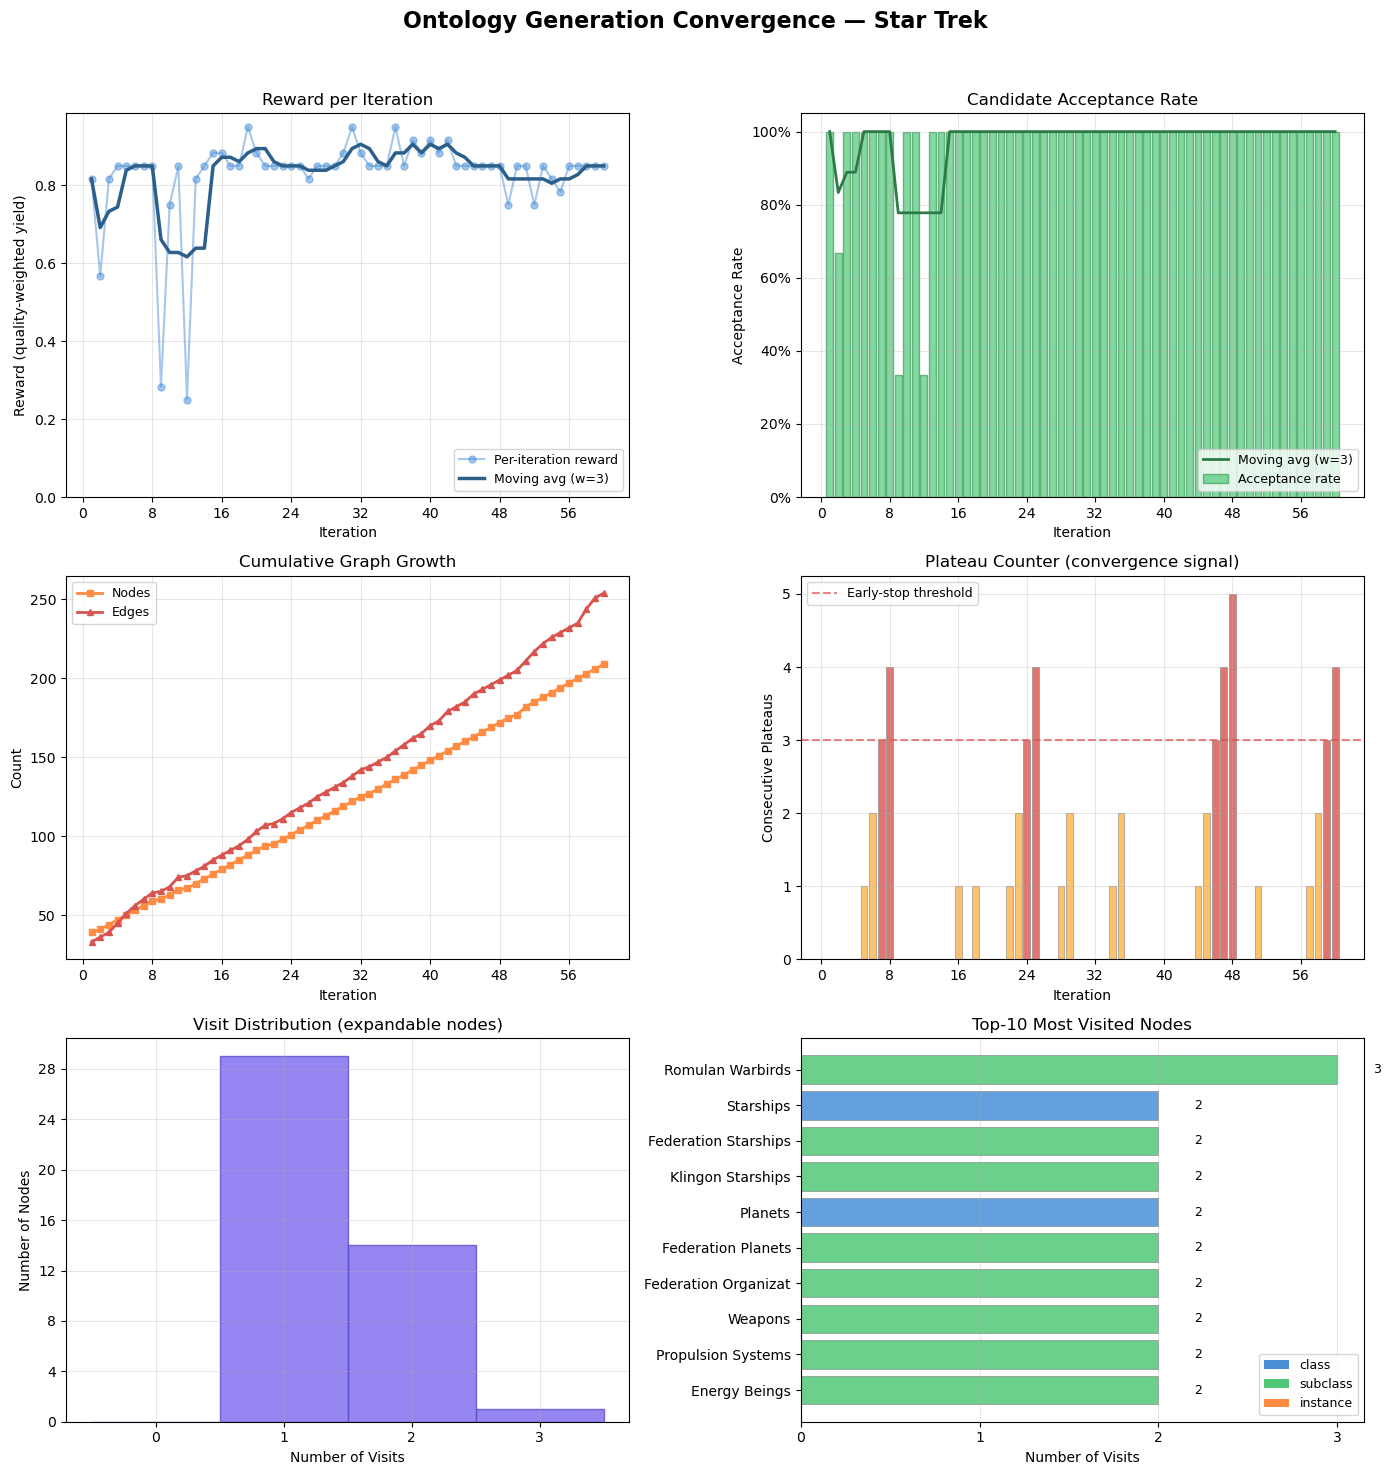


Pipeline complete!
Final graph: 209 nodes, 254 edges


In [6]:
# Run full generation pipeline (seed + validate + expand loop + serialize)
print(f"Running full pipeline with max_iterations={MAX_ITERATIONS}...")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"Exploration constant (UCB1): {EXPLORATION_CONSTANT}")
print(f"IAEDU request policy: {agent.describe_request_policy()}")
print(f"Ontology worker count: {ontology.max_workers}\n")

ontology.generate_ontology()

# Post-run audit
print(ontology.history.summary())      # formatted summary
df = ontology.history.to_dataframe()   # pandas DataFrame
ontology.plot_convergence()            # matplotlib convergence charts

print(f"\nPipeline complete!")
print(f"Final graph: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")

In [7]:
# Display expansion statistics
print("\nExpansion Statistics:")
print(f"Total nodes in final ontology: {ontology.ontology_graph.number_of_nodes()}")
print(f"Total edges in final ontology: {ontology.ontology_graph.number_of_edges()}")

# Count nodes by level
print(f"\nNodes by level:")
for level in DEFAULT_LEVEL_SCHEMA:
    nodes_at_level = [n for n, d in ontology.ontology_graph.nodes(data=True) if d.get('level') == level.name]
    print(f"  {level.name}: {len(nodes_at_level)} nodes")

# Show UCB1 bandit statistics
print(f"\nUCB1 Bandit Statistics (node selection):")
if hasattr(ontology, 'bandit_stats') and ontology.bandit_stats:
    for node, stats in sorted(ontology.bandit_stats.items(), key=lambda x: x[1]['n_visits'], reverse=True)[:5]:
        visits = stats.get('n_visits', 0)
        reward = stats.get('total_reward', 0.0)
        mean_reward = reward / visits if visits > 0 else 0
        print(f"  {node}: {visits} visits, avg reward = {mean_reward:.2f}")
else:
    print("  (Bandit statistics not available)")


Expansion Statistics:
Total nodes in final ontology: 209
Total edges in final ontology: 254

Nodes by level:
  class: 7 nodes
  subclass: 37 nodes
  instance: 165 nodes

UCB1 Bandit Statistics (node selection):
  (Bandit statistics not available)


## Phase 4: RDF Serialization

Convert the expanded ontology to RDF triples and serialize to standard formats (Turtle, XML, JSON-LD).

In [8]:
# Build RDF graph from the ontology
print("Building RDF graph from ontology...")
ontology.build_ontology()

if ontology.rdf is not None:
    num_triples = len(ontology.rdf)
    print(f"RDF graph built: {num_triples} triples")
else:
    print("ERROR: RDF graph construction failed.")

2026-04-08 01:01:05,501 | INFO | ontogen.ontology | RDF ontology built successfully: 507 triples


Building RDF graph from ontology...
RDF graph built: 507 triples


In [9]:
# Serialize to Turtle format
print("Serializing ontology to Turtle format...")
turtle_output = ontology.serialize_ontology(format="turtle")

# Display first 50 lines of Turtle output
print("\nTurtle Output (first 50 lines):")
lines = turtle_output.split('\n')
for line in lines[:50]:
    print(line)

if len(lines) > 50:
    print(f"... ({len(lines) - 50} more lines)")

Serializing ontology to Turtle format...

Turtle Output (first 50 lines):
@prefix ex: <http://example.org/ontology/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:Alien_Species_Representatives a rdfs:Class ;
    rdfs:label "Alien Species Representatives" ;
    rdfs:subClassOf ex:Characters .

ex:Ancient_Civilizations_Planets a rdfs:Class ;
    rdfs:label "Ancient Civilizations' Planets" ;
    rdfs:subClassOf ex:Planets .

ex:Aquatic_Species a rdfs:Class ;
    rdfs:label "Aquatic Species" ;
    rdfs:subClassOf ex:Species .

ex:Artificial_Lifeforms a rdfs:Class ;
    rdfs:label "Artificial Lifeforms" ;
    rdfs:subClassOf ex:Species .

ex:Borg_Cubes a rdfs:Class ;
    rdfs:label "Borg Cubes" ;
    rdfs:subClassOf ex:Starships .

ex:Cardassian_Galor-Class_Ships a rdfs:Class ;
    rdfs:label "Cardassian Galor-Class Ships" ;
    rdfs:subClassOf ex:Starships .

ex:Characters a ex:Borg_Incursions,
        ex:Federation-Hostile_Engagements,
        ex:Federation_Medical_Corps,


In [10]:
# Save to file
output_path = "../output/ontology_iaedu.ttl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    f.write(turtle_output)

print(f"Ontology saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Ontology saved to: ../output/ontology_iaedu.ttl
File size: 19893 bytes


## Visualization

Visualize the ontology structure both as an RDF graph and an internal DiGraph with level-based coloring.

In [11]:
# Visualize the RDF graph
print("Rendering RDF graph (via rdf2dot/graphviz)...")
try:
    ontology.visualize()
except Exception as e:
    print(f"Note: RDF visualization requires graphviz. Error: {e}")

Rendering RDF graph (via rdf2dot/graphviz)...


In [12]:
# Interactive full-page HTML graph (pyvis)

print("Rendering interactive HTML graph...")
html_path = ontology.visualize_interactive(output_path="ontology_iaedu.html")
print(f"Interactive graph saved to: {html_path}")
print("Open the HTML file in a browser for full-page pan-and-zoom exploration.")


Rendering interactive HTML graph...
ontology_iaedu.html


2026-04-08 01:01:16,002 | INFO | ontogen.ontology | Interactive RDF ontology graph saved to /workspaces/thesis-llml-onthology/notebooks/ontology_iaedu.html


Interactive graph saved to: /workspaces/thesis-llml-onthology/notebooks/ontology_iaedu.html
Open the HTML file in a browser for full-page pan-and-zoom exploration.


Rendering internal DiGraph with level-based coloring...


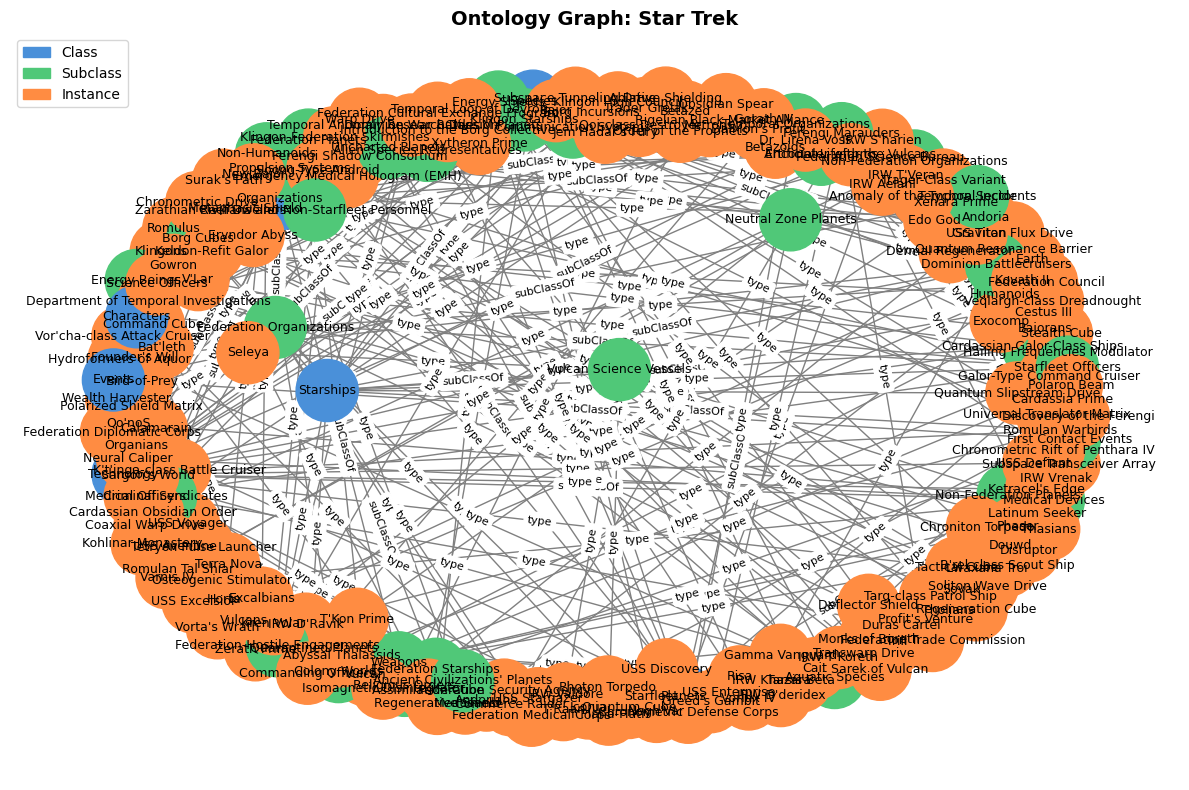

In [13]:
# Visualize the internal DiGraph with level-based node coloring
print("Rendering internal DiGraph with level-based coloring...")
try:
    ontology.visualize_graph()
except Exception as e:
    print(f"Note: DiGraph visualization requires matplotlib. Error: {e}")

In [14]:
ontology.seed.get("taxonomy", [])

[{'class': 'Species',
  'description': 'Intelligent life forms encountered in the Star Trek universe.',
  'subclasses': [{'class': 'Humanoids',
    'description': 'Species with human-like physical characteristics.',
    'instances': [{'term': 'Vulcans',
      'description': 'A logical and emotion-suppressing species from the planet Vulcan.'},
     {'term': 'Klingons',
      'description': 'A warrior species known for their honor and combat skills.'},
     {'term': 'Betazoids',
      'description': 'A telepathic species from the planet Betazed.'}]},
   {'class': 'Non-Humanoids',
    'description': 'Species with non-human physical forms.',
    'instances': [{'term': 'Tholians',
      'description': 'A crystalline species known for their web-like energy traps.'},
     {'term': 'Horta',
      'description': 'A silicon-based life form that tunnels through rock.'}]}]},
 {'class': 'Starships',
  'description': 'Spacecraft used for exploration, combat, and transportation.',
  'subclasses': [{'

In [15]:
ontology.history.config




{'exploration_constant': 0.15,
 'max_iterations': 60,
 'similarity_threshold': 70,
 'confidence_threshold': 0.5,
 'candidates_per_iteration': 3,
 'cross_link_threshold': 70,
 'retirement_limit': 3,
 'level_schema': ['class', 'subclass', 'instance']}